# Phase 4: Operations and Customer Experience

This notebook covers the operations and customer experience analyses, the most commercially actionable findings in the project. It connects what happens inside the delivery process to what customers actually feel about the marketplace, across four sub-analyses:

1. **Delivery time decomposition**: where in the process does the wait time go
2. **Review impact**: how much does each level of lateness hurt customer reviews
3. **Geographic performance**: which states are operationally underperforming
4. **Repeat purchase by first delivery**: does a bad first delivery cost retention

The fourth analysis is the headline. It connects operations directly to retention behaviour and produces the single most actionable finding in the whole project.

**Source:** `fact_orders` table in MySQL

**Outputs produced:**
- `agg_review_by_delivery_bucket` (4 rows): review distribution per delivery experience
- `agg_state_performance` (27 rows): per-state delivery and review metrics
- `agg_repeat_by_first_delivery` (4 rows): retention rate by first-delivery experience

**Key findings:**
- 74% of customer wait time is in the carrier-transit phase
- Late deliveries (4+ days) generate 75% negative reviews and a 2.17-star drop
- 8 of 9 worst-rated states are in Brazil's north/northeast; Rio de Janeiro is the urban exception
- Late delivery does *not* reduce repeat purchase, but early delivery boosts it by 31%

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['grid.alpha'] = 0.4

In [2]:
import os

USER = 'root'
PASSWORD = os.getenv('MYSQL_PASSWORD', 'YOUR_PASSWORD')
HOST = 'localhost'
PORT = 3306
DB = 'olist'

engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

with engine.connect() as conn:
    print('Connected:', conn.execute(text('SELECT VERSION()')).fetchone()[0])

Connected: 8.0.46


## Section 1: Where does the customer wait actually go?

Each delivery has three phases: payment approval, seller-to-carrier handover, and carrier-to-customer transit. Breaking the average wait time into these phases tells the operations team where investment matters.

The SQL aggregates from item grain to order grain (deduping multi-item orders), computes phase durations from timestamps, then averages by `delivery_bucket` to show how the composition changes between early, on-time, and late deliveries. 

In [3]:
delivery_breakdown = pd.read_sql("""
    WITH order_grain AS (
    	SELECT 
    		order_id, 
            delivery_bucket, 
            MIN(order_purchase_timestamp) AS purchase_ts,
            MIN(order_approved_at) AS approved_ts,
            MIN(order_delivered_carrier_date) AS carrier_pickup_ts,
            MIN(order_delivered_customer_date) AS delivered_ts
    	FROM fact_orders
        WHERE order_purchase_timestamp IS NOT NULL 
    		AND order_approved_at IS NOT NULL 
            AND order_delivered_carrier_date IS NOT NULL
            AND order_delivered_customer_date IS NOT NULL
            AND delivery_bucket IS NOT NULL
    	GROUP BY order_id, delivery_bucket
    ),
    durations AS (
    	SELECT 
    		order_id, 
            delivery_bucket, 
            TIMESTAMPDIFF(HOUR, purchase_ts, approved_ts) / 24 AS approval_phase_days,
            TIMESTAMPDIFF(HOUR, approved_ts, carrier_pickup_ts) / 24 AS handover_phase_days,
            TIMESTAMPDIFF(HOUR, carrier_pickup_ts, delivered_ts) / 24 AS transit_phase_days,
            TIMESTAMPDIFF(HOUR, purchase_ts, delivered_ts) / 24 AS total_days
    	FROM order_grain
    )
    
    SELECT 
    	delivery_bucket, 
        COUNT(*) AS orders,
        ROUND(AVG(approval_phase_days),2) AS avg_approval_days,
        ROUND(AVG(handover_phase_days), 2) AS avg_handover_days,
        ROUND(AVG(transit_phase_days), 2) AS avg_transit_days,
        ROUND(AVG(total_days), 2) AS avg_total_days
    FROM durations
    WHERE approval_phase_days >= 0
    	AND handover_phase_days >= 0
        AND transit_phase_days >= 0
    GROUP BY delivery_bucket
    ORDER BY 
    	CASE delivery_bucket 
    		WHEN 'early' THEN 1 
    		WHEN 'on_time' THEN 2
    		WHEN 'late_1to3d' THEN 3
    		WHEN 'late_4plus' THEN 4
    	END
""", engine)

print('Delivery phase breakdown by experience bucket:')
print(delivery_breakdown.to_string(index=False))

# Overall (all orders combined) phase mix
overall_breakdown = pd.read_sql("""
    WITH durations AS (
    	SELECT 
    		order_id, 
            TIMESTAMPDIFF(HOUR, MIN(order_purchase_timestamp), MIN(order_approved_at)) / 24 AS approval_days,
            TIMESTAMPDIFF(HOUR, MIN(order_approved_at), MIN(order_delivered_carrier_date)) / 24 AS handover_days,
            TIMESTAMPDIFF(HOUR, MIN(order_delivered_carrier_date), MIN(order_delivered_customer_date)) / 24 AS transit_days,
            TIMESTAMPDIFF(HOUR, MIN(order_purchase_timestamp), MIN(order_delivered_customer_date)) / 24 AS total_days
    	FROM fact_orders
        WHERE order_purchase_timestamp IS NOT NULL
    		AND order_approved_at IS NOT NULL
            AND order_delivered_carrier_date IS NOT NULL 
            AND order_delivered_customer_date IS NOT NULL
    	GROUP BY order_id
    )
    SELECT 
    	COUNT(*) AS orders,
        ROUND(AVG(approval_days), 2) AS avg_approval_days,
        ROUND(AVG(handover_days), 2) AS avg_handover_days, 
        ROUND(AVG(transit_days), 2) AS avg_transit_days,
        ROUND(AVG(total_days), 2) AS avg_total_days
    FROM durations
    WHERE approval_days >= 0 AND handover_days >= 0 AND transit_days >= 0
""", engine)

print('\nOverall (all delivered orders combined):')
print(overall_breakdown.to_string(index=False))

Delivery phase breakdown by experience bucket:
delivery_bucket  orders  avg_approval_days  avg_handover_days  avg_transit_days  avg_total_days
          early   87528               0.38               2.60              7.88           10.90
        on_time    1285               0.49               4.18             14.52           19.23
     late_1to3d    1863               0.49               4.71             18.03           23.27
     late_4plus    4650               0.48               5.88             31.79           38.20

Overall (all delivered orders combined):
 orders  avg_approval_days  avg_handover_days  avg_transit_days  avg_total_days
  95326               0.39               2.82              9.34           12.58


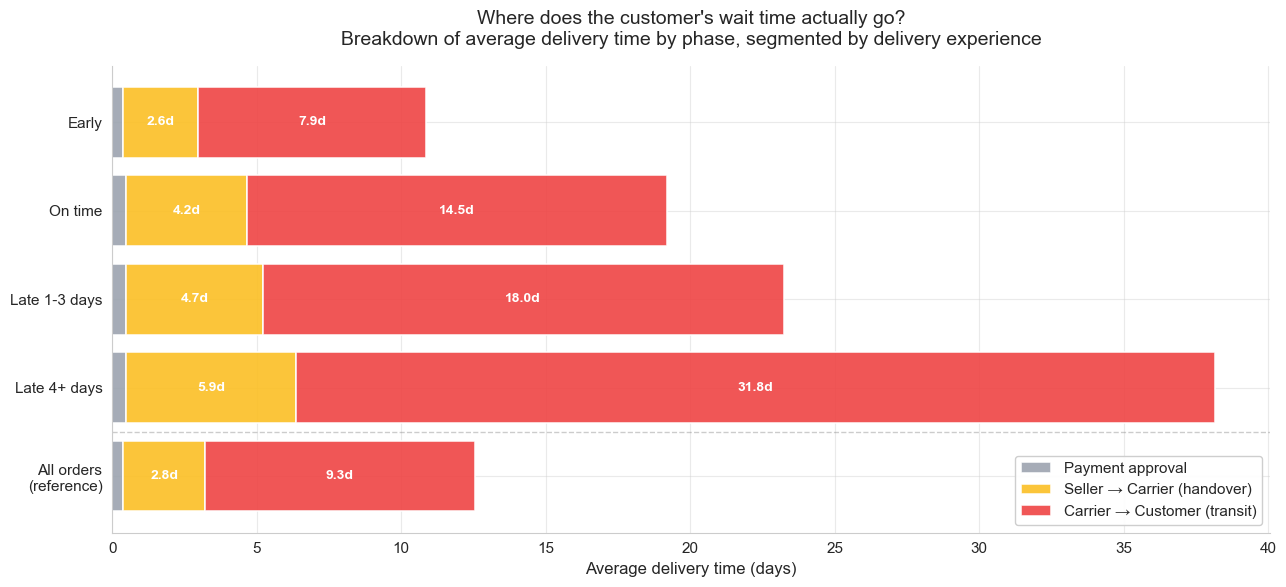


Overall phase composition:
  Payment approval                   :  0.4 days ( 3.1%)
  Seller → Carrier (handover)        :  2.8 days (22.4%)
  Carrier → Customer (transit)       :  9.3 days (74.2%)


In [4]:
bucket_order = ['early', 'on_time', 'late_1to3d', 'late_4plus']
delivery_breakdown['delivery_bucket'] = pd.Categorical(delivery_breakdown['delivery_bucket'], categories=bucket_order, ordered=True)
delivery_breakdown = delivery_breakdown.sort_values('delivery_bucket')

phase_colors = {'avg_approval_days' : '#9ca3af', 'avg_handover_days' : '#fbbf24', 'avg_transit_days' : '#ef4444'}

phase_labels = {'avg_approval_days' : 'Payment approval', 'avg_handover_days' : 'Seller → Carrier (handover)', 'avg_transit_days' : 'Carrier → Customer (transit)'}

fig, ax = plt.subplots(figsize=(13, 6))

bucket_labels = ['Early', 'On time', 'Late 1-3 days', 'Late 4+ days', 'All orders\n(reference)']
y_positions = range(len(bucket_labels))

left = [0] * len(bucket_labels)
for phase_col, color in phase_colors.items():
    values = list(delivery_breakdown[phase_col]) + [overall_breakdown[phase_col].iloc[0]]
    ax.barh(y_positions, values, left=left, color=color, edgecolor='white', linewidth=1.2, label=phase_labels[phase_col], alpha=0.9)

    for i, (l, v) in enumerate(zip(left, values)):
        if v >= 1.0:
            ax.text(l + v/2, i, f'{v:.1f}d', va='center', ha='center', fontsize=10, 
                    color='white' if color != '#9ca3af' else 'black', fontweight='bold')
    left = [l + v for l, v in zip(left, values)]

ax.set_yticks(y_positions)
ax.set_yticklabels(bucket_labels, fontsize=11)
ax.invert_yaxis()

ax.set_xlabel('Average delivery time (days)', fontsize=12)
ax.set_title('Where does the customer\'s wait time actually go?\n'
             'Breakdown of average delivery time by phase, segmented by delivery experience', 
             fontsize=14, pad=15)

ax.axhline(3.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)

ax.legend(loc='lower right', frameon=True, framealpha=0.95)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print('\nOverall phase composition:')
total = overall_breakdown['avg_total_days'].iloc[0]
for phase_col, label in phase_labels.items():
    days = overall_breakdown[phase_col].iloc[0]
    pct = days / total * 100
    print(f'  {label:35s}: {days:4.1f} days ({pct:4.1f}%)')

**Finding:** Customer wait time is dominated by the carrier transit phase (74.2% on average), with seller handover at 22.4% and payment approval at 3.1%. The critical insight is in the bucket breakdown: between on-time and severely-late orders, the transit phase quadruples (8 to 32 days) while handover only doubles. 
**Late deliveries are a carrier problem, not a seller problem.**

## Section 2: How much does lateness damage reviews?

Section 1 showed where the time goes. This section measures the customer-experience cost of that time. Joining review scores to delivery buckets quantifies the specific harm caused by each level of lateness. 

The output is two views: a box plot showing the full distribution per bucket, and a bar chart showing share of negative vs positive reviews. Together they show how much reviews vary within a bucket and how the balance of customer sentiment shifts as delivery experience worsens.

In [5]:
review_stats = pd.read_sql("""
    SELECT 
    	delivery_bucket,
        COUNT(*) AS orders,
        ROUND(AVG(review_score), 2) AS avg_review, 
        ROUND(STDDEV(review_score), 2) AS std_review,
        ROUND(SUM(CASE WHEN review_score = 1 THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_one_star,
        ROUND(SUM(CASE WHEN review_score = 5 THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_five_star,
        ROUND(SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_negative, 
        ROUND(SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_positive
    FROM (
    	SELECT DISTINCT order_id, delivery_bucket, review_score
        FROM fact_orders
        WHERE review_score IS NOT NULL
    		AND delivery_bucket IS NOT NULL) order_grain
    GROUP BY delivery_bucket
    ORDER BY 
    	CASE delivery_bucket
    		WHEN 'early' THEN 1
            WHEN 'on_time' THEN 2
            WHEN 'late_1to3d' THEN 3
            WHEN 'late_4plus' THEN 4
    	END
""", engine)

print('Review distribution by delivery bucket:')
print(review_stats.to_string(index=False))

raw_reviews = pd.read_sql("""
    SELECT DISTINCT order_id, delivery_bucket, review_score
    FROM fact_orders
    WHERE review_score IS NOT NULL AND delivery_bucket IS NOT NULL
""", engine)

print(f'\nRaw reviews loaded: {len(raw_reviews):,} orders')
print('Distribution by bucket:')
print(raw_reviews['delivery_bucket'].value_counts())

Review distribution by delivery bucket:
delivery_bucket  orders  avg_review  std_review  pct_one_star  pct_five_star  pct_negative  pct_positive
          early   88163        4.29        1.15           6.6           62.4           9.2          82.8
        on_time    1280        4.03        1.25           8.5           50.6          12.4          73.7
     late_1to3d    1852        3.29        1.59          25.1           33.2          32.1          53.2
     late_4plus    4537        1.86        1.36          65.4            9.9          74.7          16.0

Raw reviews loaded: 95,832 orders
Distribution by bucket:
delivery_bucket
early         88163
late_4plus     4537
late_1to3d     1852
on_time        1280
Name: count, dtype: int64


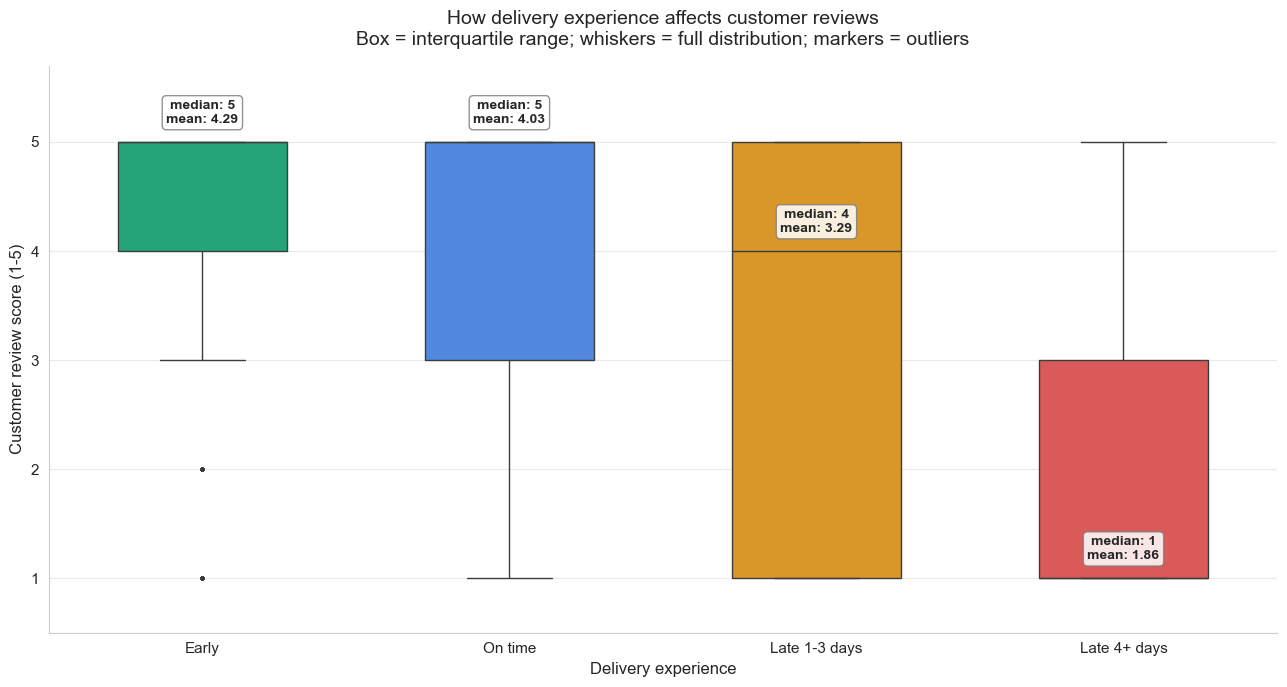

In [6]:
bucket_order = ['early', 'on_time', 'late_1to3d', 'late_4plus']
raw_reviews['delivery_bucket'] = pd.Categorical(raw_reviews['delivery_bucket'], categories=bucket_order, ordered=True)
raw_reviews = raw_reviews.sort_values('delivery_bucket')

# Visual conventions
bucket_colors = {'early': '#10b981', 'on_time': '#3b82f6', 'late_1to3d': '#f59e0b', 'late_4plus': '#ef4444'}

fig, ax = plt.subplots(figsize=(13,7))

sns.boxplot(x='delivery_bucket', y='review_score', data=raw_reviews, hue='delivery_bucket', palette=bucket_colors, legend=False, ax=ax, width=0.55, fliersize=2)

for i, bucket in enumerate(bucket_order):
    median = raw_reviews[raw_reviews['delivery_bucket'] == bucket]['review_score'].median()
    mean = raw_reviews[raw_reviews['delivery_bucket'] == bucket]['review_score'].mean()
    ax.annotate(
        f'median: {median:.0f}\nmean: {mean:.2f}', 
        xy=(i, median), xytext=(i, median + 0.15), ha='center', va='bottom', 
        fontsize=10, fontweight='bold', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.85))

ax.set_xticks(range(len(bucket_order)))
ax.set_xticklabels(['Early', 'On time', 'Late 1-3 days', 'Late 4+ days'])

ax.set_xlabel('Delivery experience', fontsize=12)
ax.set_ylabel('Customer review score (1-5)', fontsize=12)
ax.set_title('How delivery experience affects customer reviews\n'
             'Box = interquartile range; whiskers = full distribution; markers = outliers', 
             fontsize=14, pad=15)
ax.set_ylim(0.5, 5.7)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

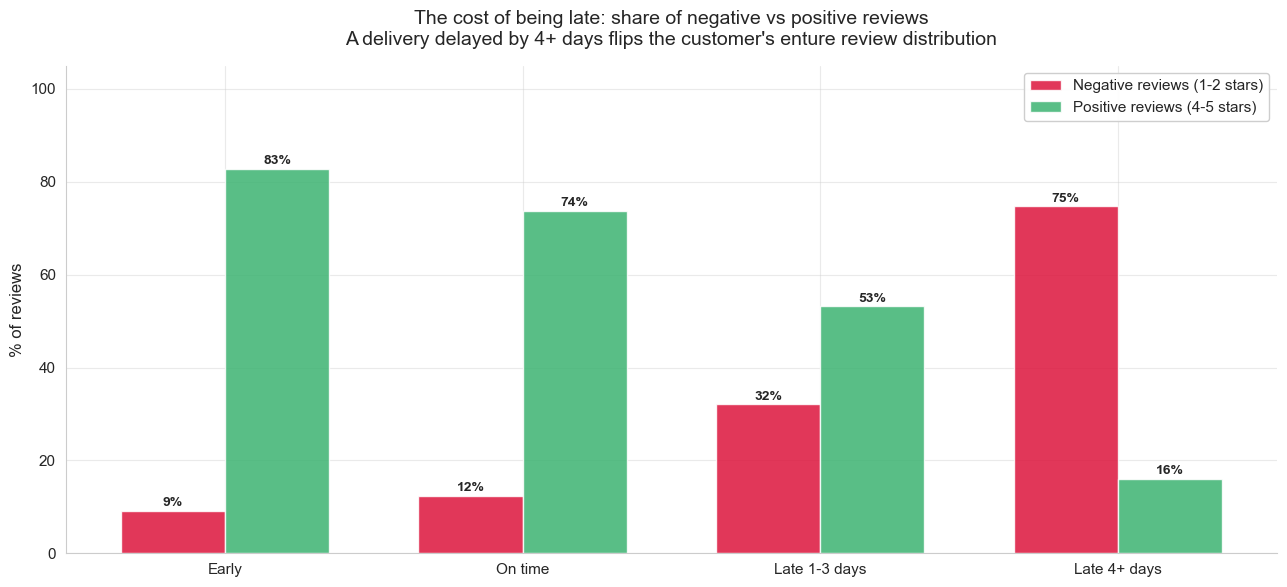

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

x_positions = np.arange(len(review_stats))
width = 0.35

bars_neg = ax.bar(x_positions - width/2, review_stats['pct_negative'], width, color='crimson', edgecolor='white', 
                  linewidth=1, label='Negative reviews (1-2 stars)', alpha=0.85)
bars_pos = ax.bar(x_positions + width/2, review_stats['pct_positive'], width, color='mediumseagreen', edgecolor='white', 
                  linewidth=1, label='Positive reviews (4-5 stars)', alpha=0.85)

for bar in list(bars_neg) + list(bars_pos):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x_positions)
ax.set_xticklabels(['Early', 'On time', 'Late 1-3 days', 'Late 4+ days'])
ax.set_ylabel('% of reviews', fontsize=12)
ax.set_title('The cost of being late: share of negative vs positive reviews\n'
             'A delivery delayed by 4+ days flips the customer\'s enture review distribution', 
             fontsize=14, pad=15)
ax.legend(loc='upper right', framealpha=0.95)
ax.set_ylim(0, 105)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


**Finding:** Late delivery has a sharp negative effect on customer reviews. Going from on-time to 4+ days late drops the average score by 2.17 stars (4.03 to 1.86), with the median falling from 5 stars to 1 star. 75% of severely-late deliveries receive 1 or 2 stars. The pattern indicates that customers do not simply express disappointment at this level of delay, they actively express dissatisfaction.

In [8]:
review_stats.to_sql('agg_review_by_delivery_bucket', engine, if_exists='replace', index=False)
print(f'Saved agg_review_by_delivery_bucket ({len(review_stats)} buckets) to MySQL.')

Saved agg_review_by_delivery_bucket (4 buckets) to MySQL.


## Section 3: Geographic performance

Aggregating per state shows whether delivery and review issues are spread evenly or clustered geographically. Brazil's size makes this question particularly relevant since logistics infrastructure varies enormously between regions. 

Two views are produced: states ranked by average delivery time (with late-share shown as colour) and states ranked by review score (with green-to-red colour matching the rating). Together they reveal where to focus operational investment. 

In [9]:
state_perf = pd.read_sql("""
    WITH order_grain AS (
    	SELECT DISTINCT order_id, customer_state, total_payment_value, delivery_days_total, delivery_vs_estimate_days, delivery_bucket, review_score
        FROM fact_orders
        WHERE customer_state IS NOT NULL AND delivery_days_total IS NOT NULL AND review_score IS NOT NULL
    )
    SELECT 
    	customer_state,
        COUNT(*) AS orders,
        ROUND(SUM(total_payment_value), 2) AS total_revenue,
        ROUND(SUM(total_payment_value) / COUNT(*), 2) AS avg_order_value, 
        ROUND(AVG(delivery_days_total), 1) AS avg_delivery_days,
        ROUND(AVG(review_score), 2) AS avg_review_score,
        ROUND(SUM(CASE WHEN delivery_bucket IN('late_1to3d', 'late_4plus') THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_late,
        ROUND(SUM(CASE WHEN delivery_bucket = 'late_4plus' THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_very_late,
        ROUND(SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_neg_reviews
    FROM order_grain
    GROUP BY customer_state
    ORDER BY orders DESC
""", engine) 

print(f'States analysed: {len(state_perf)}')
print('\nTop 10 states by order volume:')
print(state_perf.head(10).to_string(index=False))
print('\nBottom 10 states by order volume ( likely the underserved markets):')
print(state_perf.tail(10).to_string(index=False))

States analysed: 27

Top 10 states by order volume:
customer_state  orders  total_revenue  avg_order_value  avg_delivery_days  avg_review_score  pct_late  pct_very_late  pct_neg_reviews
            SP   40266     5736983.42           142.48                8.7              4.25       4.4            2.7             10.7
            RJ   12211     2026600.23           165.97               15.2              3.97      11.9            9.5             18.3
            MG   11285     1804521.41           159.90               11.9              4.19       4.5            2.9             11.8
            RS    5326      858654.84           161.22               15.2              4.18       6.0            4.5             11.9
            PR    4900      779570.14           159.10               11.9              4.24       4.0            2.4             10.9
            SC    3519      586512.00           166.67               14.8              4.13       8.1            5.5             13.0
          

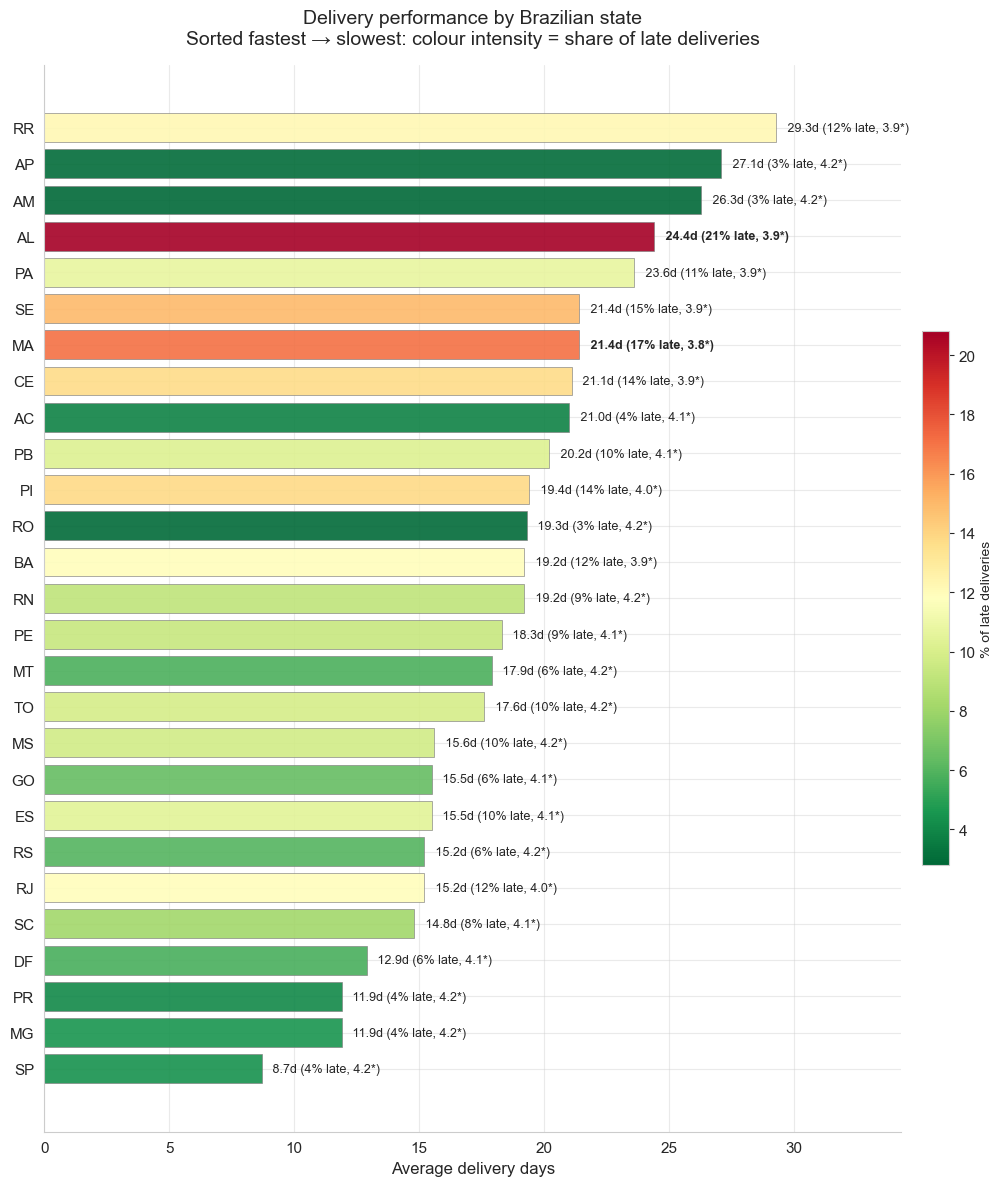

In [10]:
state_perf_sorted = state_perf.sort_values('avg_delivery_days', ascending=True)

fig, ax = plt.subplots(figsize=(11, 12))

norm = plt.Normalize(state_perf_sorted['pct_late'].min(), state_perf_sorted['pct_late'].max())

colors = plt.cm.RdYlGn_r(norm(state_perf_sorted['pct_late']))

bars = ax.barh(state_perf_sorted['customer_state'], state_perf_sorted['avg_delivery_days'], color=colors, edgecolor='gray', linewidth=0.5, alpha=0.9)

for bar, days, pct_late, review in zip(bars, state_perf_sorted['avg_delivery_days'], state_perf_sorted['pct_late'], state_perf_sorted['avg_review_score']):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() /2, 
        f' {days:.1f}d ({pct_late:.0f}% late, {review:.1f}*)',
        va='center', ha='left', fontsize=9, fontweight='bold' if pct_late > 15 else 'normal')

ax.set_xlabel('Average delivery days', fontsize=12)
ax.set_ylabel('')
ax.set_title('Delivery performance by Brazilian state\n'
             'Sorted fastest → slowest: colour intensity = share of late deliveries', 
             fontsize=14, pad=15)
ax.set_xlim(0, state_perf_sorted['avg_delivery_days'].max() + 5)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('% of late deliveries', fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

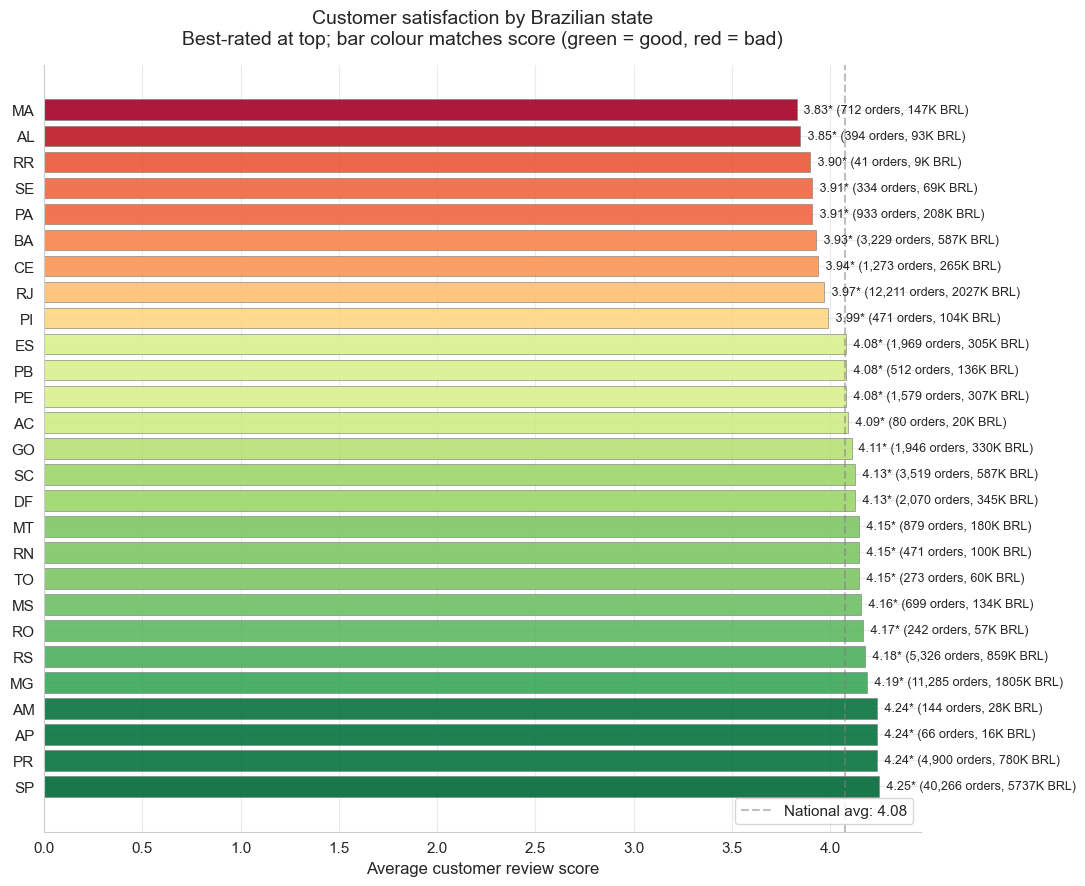

In [11]:
%matplotlib inline

state_perf_by_review = state_perf.sort_values('avg_review_score', ascending=False)

review_scores = state_perf_by_review['avg_review_score'].values
norm = plt.Normalize(vmin=review_scores.min(), vmax=review_scores.max())
cmap = plt.cm.RdYlGn
colors = [cmap(norm(score)) for score in review_scores]

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(state_perf_by_review['customer_state'], state_perf_by_review['avg_review_score'],
               color=colors, edgecolor='gray', linewidth=0.5, alpha=0.9)

for bar, review, orders, revenue in zip(bars, state_perf_by_review['avg_review_score'], state_perf_by_review['orders'], state_perf_by_review['total_revenue']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2, 
            f' {review:.2f}* ({orders:,} orders, {revenue/1000:.0f}K BRL)', 
            va='center', ha='left', fontsize=9)

ax.set_xlabel('Average customer review score', fontsize=12)
ax.set_title('Customer satisfaction by Brazilian state\n'
             'Best-rated at top; bar colour matches score (green = good, red = bad)',
             fontsize=14, pad=15)

ax.axvline(state_perf['avg_review_score'].mean(), color='gray', linestyle='--', alpha=0.5, 
           label=f'National avg: {state_perf['avg_review_score'].mean():.2f}')
ax.legend(loc='lower right')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Finding:** Nine states have review scores below the 4.08 national average: MA, AL, RR, SE, PA, BA, CE, RJ, and PI. Eight of these are in the north or northeast, where distance and rural logistics likely drive longer transit times. The exception is Rio de Janeiro, the second-largest market by volume (12,211 orders, 2.03M BRL revenue) but rated below average at 3.97. RJ suggests an urban-density problem distinct from the rural-distance challenge elsewhere. 

In [12]:
state_perf.to_sql('agg_state_performance', engine, if_exists='replace', index=False)
print(f'Saved agg_state_performance ({len(state_perf)} states) to MySQL.')

Saved agg_state_performance (27 states) to MySQL.


## Section 4: Does a bad first delivery cost retention?

This is where the operational analysis connects to actual customer behaviour. The question is "if a customer's first order arrived late, are they less likely to ever come back?"
The answer matters because it determines whether the operational improvements recommended elsewhere translate into retention upside. 

For each customer, the SQL identifies the first order using `ROW_NUMBER() over PARTITION BY customer_unique_id`, then counts total orders via a second window function. A return flag is set when a customer has 2 or more orders. The final aggregation reports return rates by the first-order's delivery bucket.

The result contradicts what the operational findings above would predict, and warrants careful interpretation.

In [13]:
repeat_by_first_delivery = pd.read_sql("""
    WITH order_grain AS (
    	SELECT DISTINCT order_id, customer_unique_id, order_purchase_timestamp, delivery_bucket
        FROM fact_orders
        WHERE customer_unique_id IS NOT NULL
    		AND order_purchase_timestamp IS NOT NULL
            AND delivery_bucket IS NOT NULL
    ), 
    customer_orders AS (
    	SELECT order_id, customer_unique_id, order_purchase_timestamp, delivery_bucket, 
    			ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY order_purchase_timestamp ASC) AS rn,
                COUNT(*) OVER (PARTITION BY customer_unique_id) AS total_orders
    	FROM order_grain
    ), 
    first_orders AS (
    	SELECT customer_unique_id, delivery_bucket AS first_delivery_bucket, total_orders, 
    			CASE WHEN total_orders >= 2 THEN 1 ELSE 0 END AS returned
    	FROM customer_orders
        WHERE rn=1
    )
    SELECT 
    	first_delivery_bucket, 
        COUNT(*) AS customers,
        SUM(returned) AS returning_customers,
        ROUND(SUM(returned) / COUNT(*) * 100, 2) AS return_rate_pct,
        ROUND(AVG(total_orders), 2) AS avg_orders_per_customer
    FROM first_orders
    GROUP BY first_delivery_bucket
    ORDER BY CASE first_delivery_bucket
    			WHEN 'early' THEN 1
                WHEN 'on_time' THEN 2
                WHEN 'late_1to3d' THEN 3
                WHEN 'late_4plus' THEN 4
    		END
""", engine)

print('Repeat purchase rate by first-order delivery experience:')
print(repeat_by_first_delivery.to_string(index=False))

on_time_rate = repeat_by_first_delivery[repeat_by_first_delivery['first_delivery_bucket'] == 'on_time']['return_rate_pct'].iloc[0]
late_4plus_rate = repeat_by_first_delivery[repeat_by_first_delivery['first_delivery_bucket'] == 'late_4plus']['return_rate_pct'].iloc[0]

print('\nHeadline finding:')
print(f' On-time first delivery: {on_time_rate:.2f}% return rate')
print(f' 4+ days late first delivery: {late_4plus_rate:.2f}% return rate')
print(f' Absolute drop: {on_time_rate - late_4plus_rate:.2f} percentage points')
print(f' Relative drop: {(1 - late_4plus_rate/on_time_rate) * 100:.0f}%')

Repeat purchase rate by first-order delivery experience:
first_delivery_bucket  customers  returning_customers  return_rate_pct  avg_orders_per_customer
                early      85749               2613.0             3.05                     1.03
              on_time       1247                 29.0             2.33                     1.03
           late_1to3d       1820                 43.0             2.36                     1.03
           late_4plus       4542                116.0             2.55                     1.03

Headline finding:
 On-time first delivery: 2.33% return rate
 4+ days late first delivery: 2.55% return rate
 Absolute drop: -0.22 percentage points
 Relative drop: -9%


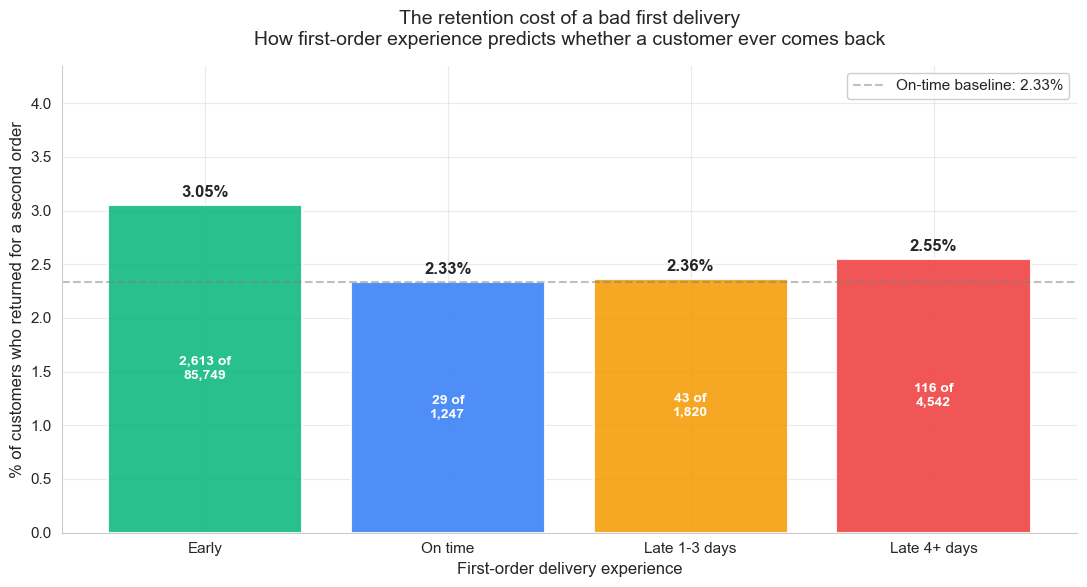

In [14]:
bucket_order = ['early', 'on_time', 'late_1to3d', 'late_4plus']
repeat_by_first_delivery['first_delivery_bucket'] = pd.Categorical(repeat_by_first_delivery['first_delivery_bucket'], categories=bucket_order, ordered=True)
repeat_by_first_delivery = repeat_by_first_delivery.sort_values('first_delivery_bucket')

pretty_labels = ['Early', 'On time', 'Late 1-3 days', 'Late 4+ days']

BUCKET_COLORS = {'early':'#10b981', 'on_time':'#3b82f6', 'late_1to3d':'#f59e0b', 'late_4plus':'#ef4444'}
colors = [BUCKET_COLORS[b] for b in repeat_by_first_delivery['first_delivery_bucket']]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(pretty_labels, repeat_by_first_delivery['return_rate_pct'], color=colors, edgecolor='white', linewidth=1.5, alpha=0.9)

for bar, row in zip(bars, repeat_by_first_delivery.itertuples()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f'{row.return_rate_pct:.2f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2, h/2, f'{int(row.returning_customers):,} of\n{int(row.customers):,}', 
        ha='center', va='center', fontsize=10, color='white', fontweight='bold')

on_time_val = repeat_by_first_delivery[repeat_by_first_delivery['first_delivery_bucket'] == 'on_time']['return_rate_pct'].iloc[0]
ax.axhline(on_time_val, color='gray', linestyle='--', alpha=0.5, label=f'On-time baseline: {on_time_val:.2f}%')

ax.set_xlabel('First-order delivery experience', fontsize=12)
ax.set_ylabel('% of customers who returned for a second order', fontsize=12)
ax.set_title('The retention cost of a bad first delivery\n'
             'How first-order experience predicts whether a customer ever comes back', 
             fontsize=14, pad=15)
ax.set_ylim(0, repeat_by_first_delivery['return_rate_pct'].max() + 1.3)
ax.legend(loc='upper right', framealpha=0.95)

for spine in ['top', 'right']: 
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Finding:** Lateness does not reduce repeat purchase. On-time, late 1-3 days, and late 4+ days customers all return at roughly 2.3-2.6%. What sets the early-delivery customers apart is that they return at 3.05%, a 31% lift over on-time. Olist's customers do not punish lateness, they reward early delivery. The retention lever is not "avoid being late", it is "tighten the delivery promise so more orders arrive early". This becomes Recommendation 3 in the commercial memo. 

In [15]:
repeat_by_first_delivery.to_sql('agg_repeat_by_first_delivery', engine, if_exists='replace', index=False)
print('Saved agg_repeat_by_first_delivery to MySQL.')

Saved agg_repeat_by_first_delivery to MySQL.


## Summary

The four sub-analyses build one operational story:

The customer wait is dominated by carrier transit. When transit fails (late deliveries), reviews drop sharply. The failures cluster in specific states, mainly the north and northeast plus Rio de Janeiro. Retention is not damaged by lateness, yet early delivery boosts it by 31%. The operational levers are therefore two-sided: invest in carrier quality where failures cluster, and tighten the delivery promise so more orders fall into the "early" classification. 

These findings drive Recommendations 2 and 3 in the commercial memo. 